# 05 Rank 0 vs Rank 1: Which Signal Carries the Information?

The paper's hardest split: ~0.96 with 1000 features on conductor $[1, 10^5]$, ~0.7 with 10. (Narrower conductor windows do better — this notebook's $[7500, 10^4]$ baseline reaches ~0.99, consistent with Notebook 03's findings.) For a fixed prime $p$ and conductor range, the ensemble distributions of $\tilde a_p = \dfrac{a_p}{2\sqrt{p}}$ for rank 0 and rank 1 curves overlap heavily (HLOP Figs 9–10) — unlike rank $\geq$ 2, whose distributions are shifted markedly negative (Fig 11), which is why the {0,1}-vs-{$\geq$ 2} split is easy and this one is not. The rank 0 and rank 1 distributions differ in two subtle ways:

- **Mean.** The class-conditional mean of $a_p$ is the murmuration: $f_0(n)$ and $f_1(n)$ mirror each other (Fig 6). A linear classifier scores curves by $w \cdot v_L(E)$, and a difference in class means produces a difference in expected score — so this signal is exactly what logistic regression on raw $a_p$ can read.
- **Skew.** Rank 0 is slightly left-skewed, rank 1 slightly right-skewed, with the direction oscillating in $p$ (HLOP Section 4.4). Two distributions with equal means but opposite skew give identical expected scores for *every* linear functional — a third-moment signal is invisible to a linear model on raw $a_p$ wherever the means coincide.

Plan: a synthetic testbed with each signal independently switchable — verify which featurizations and architectures can read skew in isolation — then real curves, to measure how much the skew actually contributes there. Spoiler: on real data, the mean is nearly everything.

In [1]:
%load_ext autoreload
%autoreload 2
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from murmurations import ml
from murmurations import torch_models as tm
from murmurations.data import feature_matrix
from murmurations.features import moment_feature_matrix
from murmurations.synthetic import make_synthetic_dataset

# LogisticRegression at max_iter=2000 occasionally stops just short of
# convergence on the 3000-column moment features; the accuracies are stable,
# so silence only that warning rather than all warnings.
warnings.filterwarnings("ignore", category=ConvergenceWarning)

DATA = Path("..") / "data"
device = tm.get_device()
print("device", device)

device mps


## A. Synthetic testbed — isolate the two signals
We control mean and skew independently, so we know ground truth. First the **skew-only** regime (means identical): a linear model on raw $a_p$ *must* fail, moment features *must* recover it.

In [2]:
skew = make_synthetic_dataset(
    n_per_rank=5000, num_primes=100, mean_amp=0.0, skew_amp=2.0, seed=5
)
raw = ml.repeat_logistic(skew, [0, 1], seeds=range(3), n_features=100)
mom = ml.repeat_logistic(
    skew,
    [0, 1],
    seeds=range(3),
    n_features=100,
    featurizer=moment_feature_matrix,
)
print(
    f"logistic(raw a_p)         {raw['acc_mean']:.3f}   "
    f"<- chance: blind to skew"
)
print(f"logistic(moment features) {mom['acc_mean']:.3f}   <- skew unlocked")

logistic(raw a_p)         0.505   <- chance: blind to skew
logistic(moment features) 0.847   <- skew unlocked


### Does an MLP discover the skew feature on its own?

Skew is a third-moment statistic: for classes with matched mean and variance, $\mathbb{E}\left[\tilde{a}_p^{3}\right]$ is the quantity that differs. A linear model on the *cubed* features detects it (that is what the moment features do above). An MLP can certainly *represent* $x \mapsto x^3$ — $\tilde{a}_p \in [-1, 1]$, and a ReLU network approximates any continuous function on a bounded interval, so if it fails from raw inputs, the bottleneck is optimization, not representation.

In [3]:
def mlp_acc(df, featurizer, npr, hidden=(256, 128), drop=0.3, epochs=100):
    X = featurizer(df, num_primes=npr)
    y = df["rank"].to_numpy()
    # Split FIRST, then fit the scaler on training rows only -- fitting on
    # the full matrix leaks validation statistics into the normalization.
    Xtr, Xva, ytr, yva = train_test_split(
        X, y, test_size=0.2, random_state=0, stratify=y
    )
    scaler = StandardScaler().fit(Xtr)
    tl, vl = tm.make_loaders_from_arrays(
        scaler.transform(Xtr),
        ytr,
        scaler.transform(Xva),
        yva,
        batch_size=256,
        device=device,
    )
    m = tm.MLP(X.shape[1], 2, hidden=hidden, p_drop=drop)
    h = tm.train(
        m,
        tl,
        vl,
        device,
        epochs=epochs,
        lr=1e-3,
        patience=15,
        scheduler="plateau",
        verbose=False,
    )
    return max(h.val_acc)


print(
    f"MLP(raw a_p)     {mlp_acc(skew, feature_matrix, 100):.3f}   "
    f"<- still ~chance"
)
print(
    f"MLP(moments)     {mlp_acc(skew, moment_feature_matrix, 100):.3f}   "
    f"<- works"
)

MLP(raw a_p)     0.513   <- still ~chance
MLP(moments)     0.823   <- works


**Takeaway (synthetic, skew-only regime):** the MLP never finds the third-moment signal from raw inputs — the bottleneck is optimization, not representation — while hand-built moment features unlock it even for a linear model. In *this* regime, feature engineering beats architecture. Two caveats coming: Notebook 06 shows that the right architecture (a 1-D CNN) finds this signal from raw inputs after all, and section B below asks whether the skew matters on real curves in the first place.

## B. Real data — rank 0 vs 1, conductor [7500, 10000]
Load the dataset from Notebook 01 and apply the same recipe. (If the parquet isn't there yet, run Notebook 01 first.)

In [4]:
df = pd.read_parquet(DATA / "ec_7500_10000_r012_1000ap.parquet")
df01 = df[df["rank"].isin([0, 1])].copy()
df01.groupby("rank").size()

rank
0    4328
1    5194
dtype: int64

In [5]:
base = ml.repeat_logistic(df01, [0, 1], seeds=range(5), n_features=1000)
moms = ml.repeat_logistic(
    df01,
    [0, 1],
    seeds=range(5),
    n_features=1000,
    featurizer=moment_feature_matrix,
)
print(
    f"logistic(raw a_p)         {base['acc_mean']:.3f} +- {base['acc_std']:.3f}"
)
print(
    f"logistic(moment features) {moms['acc_mean']:.3f} +- {moms['acc_std']:.3f}"
)

logistic(raw a_p)         0.987 +- 0.001
logistic(moment features) 0.977 +- 0.001


In [6]:
print(
    f"MLP(raw a_p)       {mlp_acc(df01, feature_matrix, 1000, epochs=60):.3f}"
)
print(
    f"MLP(moments 1,2,3) "
    f"{mlp_acc(df01, moment_feature_matrix, 1000, epochs=60):.3f}"
)

MLP(raw a_p)       0.987
MLP(moments 1,2,3) 0.986


## C. How many primes do you need? (accuracy vs d)

Reproduces the paper's observation that 10 primes $\Rightarrow$ ~0.7 while 1000 $\Rightarrow$ ~0.96, and tests whether moment features help at *any* prime count. (3 seeds per point; the non-monotonicity around d = 200–500 is seed noise.)

d=  10  raw=0.687  moments=0.695
d=  25  raw=0.818  moments=0.817
d=  50  raw=0.905  moments=0.904
d= 100  raw=0.965  moments=0.962
d= 200  raw=0.977  moments=0.961
d= 500  raw=0.973  moments=0.970
d=1000  raw=0.987  moments=0.978


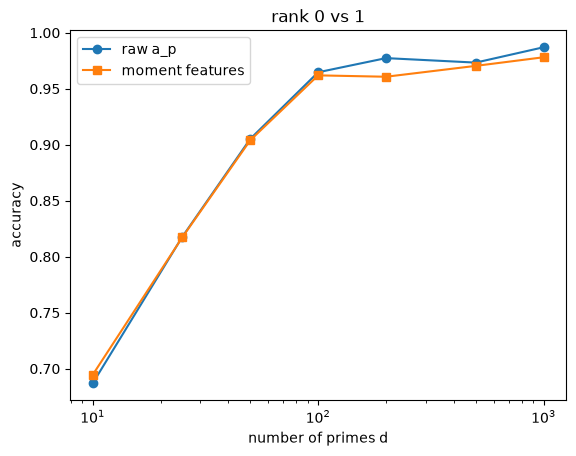

In [7]:
ds = [10, 25, 50, 100, 200, 500, 1000]
rows = []
for d in ds:
    r = ml.repeat_logistic(df01, [0, 1], seeds=range(3), n_features=d)[
        "acc_mean"
    ]
    mfn = ml.repeat_logistic(
        df01,
        [0, 1],
        seeds=range(3),
        n_features=d,
        featurizer=moment_feature_matrix,
    )["acc_mean"]
    rows.append((d, r, mfn))
    print(f"d={d:4d}  raw={r:.3f}  moments={mfn:.3f}")
rows = np.array(rows)
plt.plot(rows[:, 0], rows[:, 1], "o-", label="raw a_p")
plt.plot(rows[:, 0], rows[:, 2], "s-", label="moment features")
plt.xscale("log")
plt.xlabel("number of primes d")
plt.ylabel("accuracy")
plt.legend()
plt.title("rank 0 vs 1")
plt.show()

### The real-data verdict

At every d, raw $a_p$ matches or beats the moment features — the skew signal that dominated the synthetic testbed contributes nothing measurable on real curves in this conductor range. The MLP shows the same picture — no gain from the moments (0.987 raw vs 0.986 here; single-run MLP accuracies wobble by a few thousandths across runs, but raw matched or beat moments in every run we tried). Two readings, both informative:

1. **The murmuration mean carries essentially all the linearly accessible rank signal.** The skew is real — HLOP's Section 4.4 histograms show it — but on real curves it is either redundant with the mean or too weak to move the needle once 1000 primes are available. (This experiment cannot distinguish those two; separating them would require, e.g., mean-removed features.)
2. **The moment features actively cost a little** (0.978 vs 0.987 for logistic at d = 1000): tripling the feature count adds variance for the regularized model without adding usable signal.

This is the useful kind of negative result: the synthetic testbed established what the moment features *can* detect; the real data says that signal is not where the remaining errors live.

## Next: exploit the *sequence* structure

Logistic regression models and MLPs are permutation invariant — permute the 1000 columns and retrain, and nothing changes. But the discriminative signal oscillates smoothly in $n$ (the PC1 weights, Fig 5), so adjacent primes carry related information that a bag-of-features model cannot pool. Notebook 06 asks whether a 1-D CNN convolving along the prime axis can exploit that ordering, and, given this notebook's verdict that the mean signal dominates, whether it can beat the 0.987 linear baseline at all.

The diagnostic that keeps us honest there: **shuffle the prime axis and retrain.** Logistic/MLP accuracy must be unchanged; if the CNN's edge is genuinely about sequence structure, shuffling must destroy it. If the CNN survives the shuffle, its advantage came from something else — weight sharing, not locality.